In [1]:
from pathlib import Path
from brf_lightning.utils.init_from_cfg import main

dm, model = main(Path("configs/bearing/thl/speed_scale_brf.yaml"))


Seed set to 42



Datamodule summary


global μ=0.000, σ=0.272
Data split summary (windows per split):
split                 test  train   val
file       label rpm                   
fAII10.csv 1     10    0.0   97.0   0.0
fAII20.csv 1     20   49.0    0.0  49.0
fAII30.csv 1     30    0.0   97.0   0.0
fIII10.csv 2     10    0.0   97.0   0.0
fIII20.csv 2     20   49.0    0.0  49.0
fIII30.csv 2     30    0.0   97.0   0.0
n10.csv    0     10    0.0   97.0   0.0
n20.csv    0     20   49.0    0.0  49.0
n30.csv    0     30    0.0   97.0   0.0


  train windows: 582
  val   windows: 147
  test  windows: 147

Model summary
   | Name               | Type                   | Params | Mode 
-----------------------------------------------------------------------
0  | backbone           | SpeedScaledBRFBackbone | 4.4 K  | train
1  | backbone.brfc      | BRFCell                | 4.3 K  | train
2  | backbone.readout   | LICell                 | 132    | train
3  | backbone.post_gain | ReadoutGain            | 1      | train
4  | criterion          | NLLLoss                | 0      | train
5  | train_metrics      | MetricCollection       | 0      | train
6  | train_metrics.acc  | MulticlassAccuracy     | 0      | train
7  | train_metrics.f1   | MulticlassF1Score      | 0      | train
8  | val_metrics        | MetricCollection       | 0      | train
9  | val_metrics.acc    | MulticlassAccuracy     | 0      | train
10 | val_metrics.f1     | MulticlassF1Score      | 0      | train
11 | test_metrics       | MetricCollection       | 0      

In [7]:
import torch
from brf_snn.modules.rf import sustain_osc

# ───────────────── one batch ──────────────────────────────────────────
dm.setup()
x, y, speed = next(iter(dm.train_dataloader()))      # x : (B,T,1)
x = x.to(model.device)                               # (32, 8192, 1)
B, T = x.shape[:2]

cell = model.backbone.brfc
dt   = cell.dt
omega = cell.omega.abs()
b_off = cell.b_offset.abs()
p_omega = sustain_osc(omega, dt=dt)                  # constant per neuron
b_now   = p_omega - b_off                           # (64,)  effective bias

state = tuple(torch.zeros(B, 64, device=model.device) for _ in range(4))
spk_total = 0
q_max = 0.0

with torch.no_grad():
    for t in range(T):
        # build 65-dim input for this step
        x_step = x[:, t, :]                          # (B,1)
        z_prev = state[0]                            # previous spikes
        inp = torch.cat([x_step, z_prev], dim=1)
        state = cell(inp, state)                    # forward one step
        z, u, v, q = state
        spk_total += z.sum().item()
        q_max = max(q_max, float(q.abs().max()))

print(f"window RMS        : {float(x.square().mean().sqrt()):.4f}")
print(f"effective b_median: {float(b_now.median()):.4f}")
print(f"max membrane q    : {q_max:.4f}")
print(f"total spikes (32×8192) : {spk_total:.0f}")


global μ=0.000, σ=0.272
Data split summary (windows per split):
split                 test  train   val
file       label rpm                   
fAII10.csv 1     10    0.0   97.0   0.0
fAII20.csv 1     20   49.0    0.0  49.0
fAII30.csv 1     30    0.0   97.0   0.0
fIII10.csv 2     10    0.0   97.0   0.0
fIII20.csv 2     20   49.0    0.0  49.0
fIII30.csv 2     30    0.0   97.0   0.0
n10.csv    0     10    0.0   97.0   0.0
n20.csv    0     20   49.0    0.0  49.0
n30.csv    0     30    0.0   97.0   0.0


window RMS        : 0.2500
effective b_median: -0.1242
max membrane q    : 0.0000
total spikes (32×8192) : 0


In [5]:
model.backbone.brfc

BRFCell(
  (linear): Linear(in_features=65, out_features=64, bias=False)
)

In [5]:
import torch

from brf_snn.modules.rf import sustain_osc

x, _, _ = next(iter(dm.train_dataloader()))   # (B,T,1)  B may be < batch_size
x = x.permute(1, 0, 2).to(model.device)       # (T,B,1)

brf = model.backbone.brfc
ω     = brf.omega.detach().abs()
pω    = sustain_osc(ω, dt=brf.dt)
b_off = brf.b_offset.detach().abs()
b     = pω - b_off
print("min b (should be ≤0):", b.min().item())

T, B, _ = x.shape
z = x.new_zeros(B, brf.layer_size)
u = v = q = z.clone()

with torch.no_grad():
    for t in range(T):
        z, u, v, q = brf(torch.cat((x[t], z), 1), (z, u, v, q))
print("max |v|:", v.abs().max().item())


min b (should be ≤0): -0.7922993302345276
max |v|: 0.005203106440603733


In [7]:
dm.setup()                                   # rebuild after new target_rms
x, _, _ = next(iter(dm.train_dataloader()))
x = x.permute(1,0,2).to(model.device)        # (T,B,1)

brf = model.backbone.brfc
with torch.no_grad():
    z = torch.zeros(B, brf.layer_size, device=x.device)
    u, v, q = (torch.zeros_like(z) for _ in range(3))
    for t in range(x.size(0)):
        z,u,v,q = brf(torch.cat((x[t], z),1), (z,u,v,q))
print("new max |v| :", v.abs().max().item())   # expect ≥ 0.02


new max |v| : 0.006053780671209097


## One-off gain finder

In [9]:
# gain_finder.py
from pathlib import Path
import yaml
import torch
from brf_snn.modules.rf import sustain_osc
from brf_lightning.utils.init_from_cfg import _build
def suggest_gain(cfg_path: Path, batch_idx: int = 0):
    cfg = yaml.safe_load(cfg_path.read_text())

    dm = _build(cfg["data"])
    dm.setup()                              # build windows

    model = _build(cfg["model"])
    brf   = model.backbone.brfc

    # one batch -----------------------------------------------------------
    x, _, _ = list(dm.train_dataloader())[batch_idx]     # (B,T,1)
    x = x.permute(1, 0, 2)                               # (T,B,1)

    # run through membrane once (no spikes needed)
    T, B, _ = x.shape
    z = torch.zeros(B, brf.layer_size)
    u = v = q = z.clone()
    v_max = torch.zeros_like(v)

    with torch.no_grad():
        for t in range(T):
            z, u, v, q = brf(torch.cat((x[t], z), 1), (z, u, v, q))
            v_max = torch.maximum(v_max, v.abs())

    v_peak = v_max.max().item()

    # compute current boundary & target swing -----------------------------
    omega  = brf.omega.detach().abs()
    p_ω    = sustain_osc(omega, dt=brf.dt)
    b_off  = brf.b_offset.detach().abs()
    b_min  = float((p_ω - b_off).min())     # usually positive now

    # aim for max|v| ≈ 0.5 · |b_min|
    if v_peak == 0:
        raise RuntimeError("input is all zeros?")
    gain = 0.5 * abs(b_min) / v_peak

    print(f"current max|v| {v_peak:.4f}, min|b| {b_min:.4f}")
    print(f"→ multiply input by ≈ {gain:.1f}")

    # patch YAML ----------------------------------------------------------
    cfg["data"]["init_args"]["target_rms"] = float(cfg["data"]["init_args"].get("target_rms") or 1.0) * gain
    out = cfg_path.with_stem(cfg_path.stem + "_auto")
    out.write_text(yaml.dump(cfg))
    print(f"written patched config to {out}")

suggest_gain(Path("configs/bearing/thl/simple_brf.yaml"))

current max|v| 0.0108, min|b| -0.3993
→ multiply input by ≈ 18.4
written patched config to configs/bearing/thl/simple_brf_auto.yaml


In [14]:
from brf_snn.modules.rf import sustain_osc
import torch

# one batch (B,T,1) → (T,B,1)
x, _, _ = next(iter(dm.train_dataloader()))
x = x.permute(1, 0, 2).to(model.device)

brf = model.backbone.brfc
ω     = brf.omega.detach().abs()
pω    = sustain_osc(ω, dt=brf.dt)               # divergence term
b_off = brf.b_offset.detach().abs()
b     = pω - b_off                              # target for membrane

print(f"range p(ω):   {pω.min():.4f} … {pω.max():.4f}")
print(f"range b_off:  {b_off.min():.4f} … {b_off.max():.4f}")
print(f"min boundary: {b.min():.4f}")           # must be < 0 to allow spikes

# run once to get peak membrane excursion
B = x.size(1)
state = tuple(torch.zeros(B, brf.layer_size, device=x.device) for _ in range(4))
v_peak = torch.zeros_like(state[0])

with torch.no_grad():
    for t in range(x.size(0)):
        state = brf(torch.cat((x[t], state[0]), 1), state)
        v_peak = torch.maximum(v_peak, state[2].abs())   # state[2] = v

print(f"max |v| :     {v_peak.max():.4f}")


range p(ω):   -0.0005 … 0.0000
range b_off:  0.0115 … 0.3959
min boundary: -0.3964
max |v| :     0.1873


In [17]:
x,_,_ = next(iter(dm.train_dataloader()))
x = x.permute(1,0,2).to(model.device)

brf = model.backbone.brfc
with torch.no_grad():
    B = x.size(1)
    z = u = v = q = torch.zeros(B, brf.layer_size, device=x.device)
    for t in range(x.size(0)):
        z,u,v,q = brf(torch.cat((x[t], z),1), (z,u,v,q))
print("max |v| :", v.abs().max().item())


max |v| : 0.062233202159404755


In [6]:
import torch
# single training batch ------------------
x, *_ = next(iter(dm.train_dataloader()))
x = x.to("cpu")

H = model.backbone.brfc.layer_size        # ← number of neurons
B = x.size(0)                             # ← batch size

# run ONE simulation step ----------------
z, u, v, q = model.backbone.brfc(
    torch.cat((x.permute(1, 0, 2)[0],      # first time step, shape (B,1)
               torch.zeros(B, H, device="cpu")), dim=1),
    (torch.zeros(B, H, device="cpu"),)*4
)

print("max |v| :", v.abs().max().item())
print("min b   :", (-(model.backbone.brfc.b_offset)).min().item())


/home/keno/Projects/Forschung/brf-lightning/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:789: Can't initialize NVML
/home/keno/Projects/Forschung/brf-lightning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.


max |v| : 0.0
min b   : -0.04952755942940712


In [9]:
xb, *_ = next(iter(dm.train_dataloader()))
xb = xb.squeeze(-1)              # (B,T)

print("mean ± std of raw window :", xb.mean().item(), xb.std().item())

mean ± std of raw window : -2.2351742678949904e-09 0.6546593308448792


Text(0.5, 1.0, 'signal that actually enters the BRF layer')

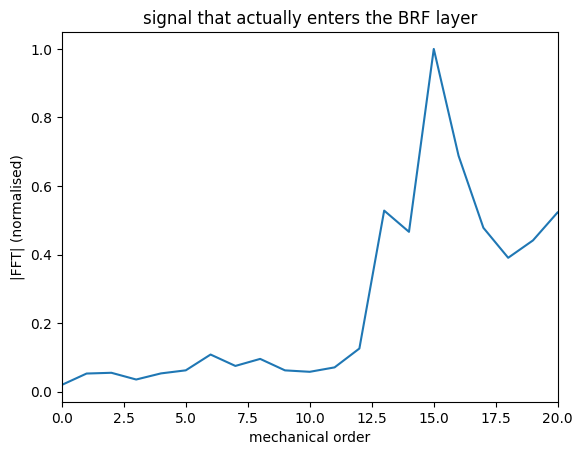

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import rfft, rfftfreq

x, _, _ = next(iter(dm.train_dataloader()))      # (B, T, 1)  after *every* DM stage
x = x[0, :, 0].numpy()                           # (T,)

spec = abs(rfft(x * np.hanning(len(x))))
frq  = rfftfreq(len(x), d=1/dm.samples_per_rev)  # cycles / rev

plt.plot(frq, spec/spec.max()); plt.xlim(0, 20)
plt.xlabel("mechanical order"); plt.ylabel("|FFT| (normalised)")
plt.title("signal that actually enters the BRF layer")


In [10]:
import torch, math
from pathlib import Path

ckpt = torch.load("results/bearing_brf_simple_order/version_7/checkpoints/epoch=29-val/loss=0.01-val/accuracy=0.00.ckpt",
                  map_location="cpu")
ω = ckpt["state_dict"]["backbone.brfc.omega"]     # (64,)

orders = (ω.abs() / (2 * math.pi)).numpy()              # rad → order
print("ω → order (rounded):")
print(sorted(round(float(o), 2) for o in orders)[:20])         # print first 20


ω → order (rounded):
[0.37, 0.39, 0.47, 0.53, 0.58, 0.69, 0.69, 0.71, 0.71, 0.78, 0.82, 0.84, 0.92, 0.95, 0.98, 1.04, 1.14, 1.16, 1.17, 1.17]


In [15]:
orders = (ω.abs() / (2*math.pi*0.01)).numpy()   # 0.01 = dt
print(sorted(round(float(o),2) for o in orders)[:20])

[36.66, 39.42, 46.63, 52.77, 57.86, 69.17, 69.25, 71.13, 71.41, 78.03, 82.36, 83.83, 91.6, 94.73, 97.67, 103.51, 114.11, 115.75, 116.67, 117.35]


learned orders:
[55.4, 56.62, 58.73, 59.08, 65.35, 65.72, 67.18, 74.85, 78.15, 78.66, 81.15, 81.64, 84.64, 99.4, 100.2, 102.3, 107.16, 107.89, 111.15, 115.68, 115.84, 125.87, 129.23, 131.47, 134.07, 140.54, 145.42, 145.9, 146.31, 146.41, 155.57, 161.68, 161.7, 163.84, 164.17, 165.99, 167.91, 170.18, 171.19, 172.65, 179.62, 180.85, 181.68, 181.84, 186.47, 188.4, 189.28, 190.2, 192.52, 195.65, 197.92, 203.27, 206.53, 209.67, 209.8, 210.36, 213.07, 217.51, 218.13, 218.38, 224.79, 226.91, 233.78, 237.45]


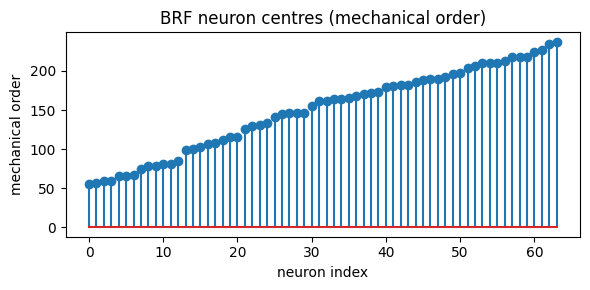

In [21]:
# -----------------------------------------------------------
# Inspect BRF neurons and convert their ω to mechanical order
# -----------------------------------------------------------
#
# Assumes:
#   * `model`     – your Lightning model
#   * backbone path = model.backbone.brfc
#   * `dt` passed to the backbone = simulation-step duration [revolutions]
#
# The code
#   1. extracts |ω| from the BRF layer                     [rad / step]
#   2. converts it to rad / rev  by dividing through dt
#   3. converts rad / rev to “mechanical order” by dividing by 2π
#   4. prints and plots the distribution
#
# -----------------------------------------------------------

import math
import torch
import matplotlib.pyplot as plt

# 1) grab the absolute eigen-frequencies ω  (rad / step)
ω_rad_per_step: torch.Tensor = (
    model.backbone.brfc.omega.detach().abs().cpu()
)

# 2) step → revolution
dt = float(model.backbone.brfc.dt)          # e.g. 0.01  rev / step
ω_rad_per_rev = ω_rad_per_step / dt         # rad / rev

# 3) rad / rev → mechanical order
orders = ω_rad_per_rev / (2 * math.pi)      # dimensionless order

# 4) show the values
orders_sorted = torch.sort(orders).values
print("learned orders:")
print([round(o.item(), 2) for o in orders_sorted])

# optional: stem plot of the order distribution
plt.figure(figsize=(6, 3))
plt.stem(orders_sorted)
plt.xlabel("neuron index")
plt.ylabel("mechanical order")
plt.title("BRF neuron centres (mechanical order)")
plt.tight_layout()
plt.show()
